# Bayesian Optimization for Hyperparameter Tuning

## Name: Stanley Nvene
## Student ID :24086496
## GitHub: https://github.com/stanleynvene/Bayesian-Optimization-for-Hyperparameter-Tuning.git

**MSc Data Science assignment notebook**  

This notebook demonstrates Bayesian Optimization for tuning a Random Forest classifier on the Breast Cancer Wisconsin dataset. It also compares Bayesian Optimization against random search under the same evaluation budget and produces two visualisations required by the tutorial:

1. a convergence plot
2. a hyperparameter importance plot

## 1. Imports

The notebook uses only standard scientific Python packages plus `scikit-learn`.

In [11]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import norm
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.model_selection import StratifiedKFold, cross_val_score

warnings.filterwarnings("ignore")
np.random.seed(42)

os.makedirs("figures", exist_ok=True)

## 2. Dataset description

The Breast Cancer Wisconsin dataset is a binary classification dataset used to predict whether a tumour is malignant or benign. It contains 569 samples with 30 numerical features extracted from digitised images of breast tissue.

This dataset is appropriate for a Bayesian Optimization tutorial because it is clean, numerical, and small enough to run quickly while still being realistic.

In [12]:
X, y = load_breast_cancer(return_X_y=True)
print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution: {np.bincount(y)}")

Feature matrix shape: (569, 30)
Target distribution: [212 357]


## 3. Search space and objective function

We tune three Random Forest hyperparameters:

- `n_estimators`: number of trees
- `max_depth`: maximum tree depth
- `min_samples_split`: minimum samples needed to split an internal node

The objective function returns the mean 5-fold stratified cross-validation accuracy.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search_space = {
    "n_estimators": (50, 300),
    "max_depth": (2, 20),
    "min_samples_split": (2, 20),
}

param_names = list(search_space.keys())
bounds = np.array(list(search_space.values()), dtype=float)


def evaluate_random_forest(params, X, y, cv):
    """Return mean CV accuracy for one hyperparameter configuration."""
    params = np.asarray(params, dtype=float)
    n_estimators = int(round(params[0]))
    max_depth = int(round(params[1]))
    min_samples_split = int(round(params[2]))

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42,
        n_jobs=1,
    )

    score = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        n_jobs=1,
    ).mean()
    return score

## 4. Helper functions

The implementation below is a compact teaching-oriented version of Bayesian Optimization. It uses:

- a Gaussian Process surrogate with a Matérn kernel
- Expected Improvement as the acquisition function
- random candidate generation followed by greedy selection of the best EI value

This is not intended to be a production optimiser, but it is fully transparent and suitable for explaining the method.

In [14]:
@dataclass
class SearchResult:
    X: np.ndarray
    y: np.ndarray
    best_params: dict
    best_score: float
    history: pd.DataFrame


rng = np.random.default_rng(42)


def sample_random_configs(n_samples, bounds, rng):
    samples = np.column_stack([
        rng.integers(low=int(low), high=int(high) + 1, size=n_samples)
        for low, high in bounds
    ])
    return samples.astype(float)



def expected_improvement(X_candidates_scaled, gp, y_best, xi=0.005):
    mu, sigma = gp.predict(X_candidates_scaled, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    improvement = mu - y_best - xi
    z = improvement / sigma
    ei = improvement * norm.cdf(z) + sigma * norm.pdf(z)
    return ei



def scale_to_unit_interval(X, bounds):
    return (X - bounds[:, 0]) / (bounds[:, 1] - bounds[:, 0])



def to_param_dict(params):
    return {
        "n_estimators": int(round(params[0])),
        "max_depth": int(round(params[1])),
        "min_samples_split": int(round(params[2])),
    }

## 5. Random search baseline

This baseline samples configurations uniformly from the same search space and uses the same total number of model evaluations as Bayesian Optimization.

In [15]:
def run_random_search(n_trials, bounds, X, y, cv, rng):
    X_trials = sample_random_configs(n_trials, bounds, rng)
    y_trials = np.array([evaluate_random_forest(x, X, y, cv) for x in X_trials])

    best_idx = int(np.argmax(y_trials))
    history = pd.DataFrame(X_trials, columns=param_names)
    history["score"] = y_trials
    history["cumulative_best_score"] = np.maximum.accumulate(y_trials)
    history["method"] = "Random Search"

    return SearchResult(
        X=X_trials,
        y=y_trials,
        best_params=to_param_dict(X_trials[best_idx]),
        best_score=float(y_trials[best_idx]),
        history=history,
    )

## 6. Bayesian Optimization implementation

The optimiser begins with a small random design, fits a Gaussian Process to the observed scores, evaluates Expected Improvement over a candidate set, and then chooses the next point with the highest acquisition value.

In [16]:
def run_bayesian_optimization(
    n_init,
    n_iterations,
    bounds,
    X,
    y,
    cv,
    rng,
    candidate_pool_size=1000,
):
    X_obs = sample_random_configs(n_init, bounds, rng)
    y_obs = np.array([evaluate_random_forest(x, X, y, cv) for x in X_obs])

    for _ in range(n_iterations):
        X_obs_scaled = scale_to_unit_interval(X_obs, bounds)

        kernel = (
            ConstantKernel(1.0, (1e-3, 1e3))
            * Matern(length_scale=np.ones(X_obs.shape[1]), nu=2.5)
            + WhiteKernel(noise_level=1e-6)
        )

        gp = GaussianProcessRegressor(
            kernel=kernel,
            normalize_y=True,
            random_state=42,
            n_restarts_optimizer=2,
        )
        gp.fit(X_obs_scaled, y_obs)

        X_candidates = sample_random_configs(candidate_pool_size, bounds, rng)
        X_candidates_scaled = scale_to_unit_interval(X_candidates, bounds)
        ei = expected_improvement(X_candidates_scaled, gp, y_obs.max())

        x_next = X_candidates[int(np.argmax(ei))]
        y_next = evaluate_random_forest(x_next, X, y, cv)

        X_obs = np.vstack([X_obs, x_next])
        y_obs = np.append(y_obs, y_next)

    best_idx = int(np.argmax(y_obs))
    history = pd.DataFrame(X_obs, columns=param_names)
    history["score"] = y_obs
    history["cumulative_best_score"] = np.maximum.accumulate(y_obs)
    history["method"] = "Bayesian Optimization"

    return SearchResult(
        X=X_obs,
        y=y_obs,
        best_params=to_param_dict(X_obs[best_idx]),
        best_score=float(y_obs[best_idx]),
        history=history,
    )

## 7. Run both methods

The two methods are given the same total budget of 25 model evaluations.

In [17]:
random_rng = np.random.default_rng(42)
bo_rng = np.random.default_rng(42)

random_result = run_random_search(
    n_trials=25,
    bounds=bounds,
    X=X,
    y=y,
    cv=cv,
    rng=random_rng,
)

bo_result = run_bayesian_optimization(
    n_init=5,
    n_iterations=20,
    bounds=bounds,
    X=X,
    y=y,
    cv=cv,
    rng=bo_rng,
    candidate_pool_size=1000,
)

summary = pd.DataFrame([
    {
        "method": "Random Search",
        "best_score": random_result.best_score,
        **random_result.best_params,
    },
    {
        "method": "Bayesian Optimization",
        "best_score": bo_result.best_score,
        **bo_result.best_params,
    },
])

summary

,method,best_score,n_estimators,max_depth,min_samples_split
0,Random Search,0.954324,265,10,2
1,Bayesian Optimization,0.956094,77,17,4


## 8. Convergence plot

This figure shows the cumulative best validation accuracy as the search progresses. It focuses on optimisation efficiency rather than only the final score.

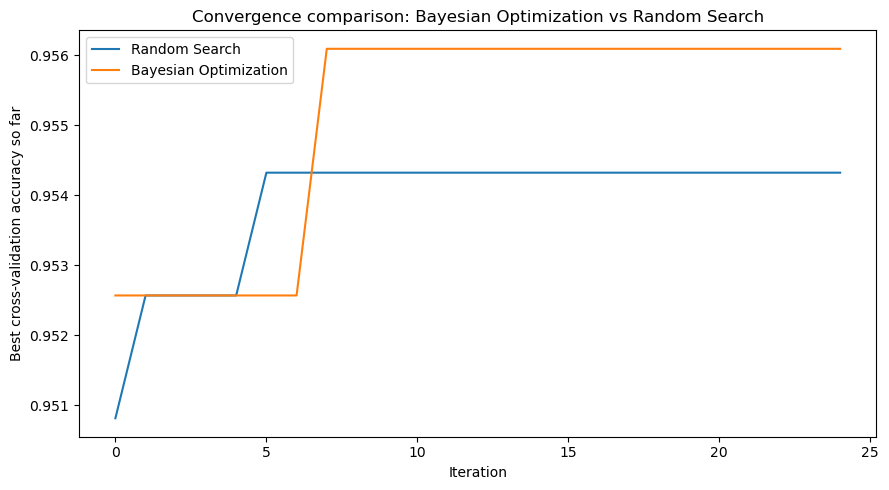

In [26]:
plt.figure(figsize=(9, 5))
plt.plot(random_result.history["cumulative_best_score"].values, label="Random Search")
plt.plot(bo_result.history["cumulative_best_score"].values, label="Bayesian Optimization")
plt.xlabel("Iteration")
plt.ylabel("Best cross-validation accuracy so far")
plt.title("Convergence comparison: Bayesian Optimization vs Random Search")
plt.legend()
plt.tight_layout()
plt.savefig("figures/Convergence_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

**Suggested interpretation:** Bayesian Optimization usually reaches a strong score in fewer evaluations because it uses the surrogate model and acquisition function to guide the search. Random search does not learn from previous trials.

## 9. Hyperparameter importance plot

To make the trial history easier to interpret, we fit a Random Forest regressor to the observed Bayesian Optimization trials and use its feature importances as a simple proxy for which hyperparameters mattered most in the search history.

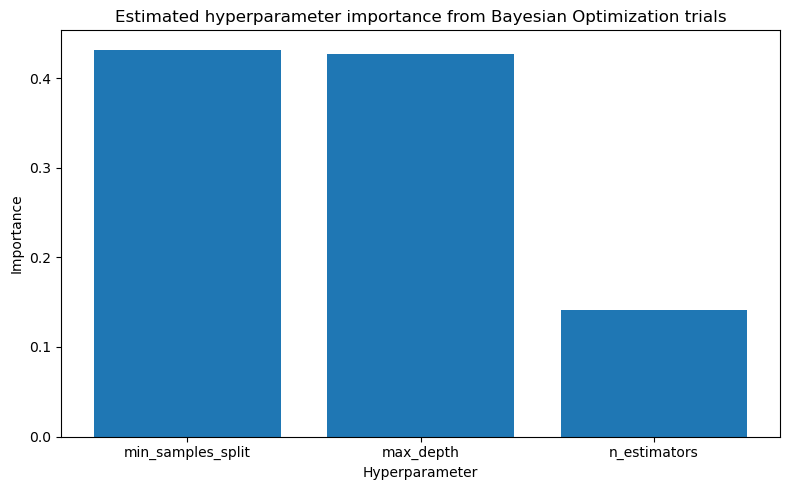

min_samples_split    0.431810
max_depth            0.427249
n_estimators         0.140941
dtype: float64

In [21]:
importance_model = RandomForestRegressor(n_estimators=300, random_state=42)
importance_model.fit(bo_result.history[param_names], bo_result.history["score"])

importance = pd.Series(importance_model.feature_importances_, index=param_names)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(importance.index, importance.values)
plt.xlabel("Hyperparameter")
plt.ylabel("Importance")
plt.title("Estimated hyperparameter importance from Bayesian Optimization trials")
plt.tight_layout()
plt.savefig("figures/Estimated hyperparameter importance from Bayesian Optimization trials.png", dpi=300, bbox_inches="tight")
plt.show()

importance

## 10. Trial history table

The table below records every Bayesian Optimization evaluation. This supports reproducibility and makes it easier to explain the sequence of decisions in the written tutorial.

In [20]:
bo_result.history

,n_estimators,max_depth,min_samples_split,score,cumulative_best_score,method
0,72.0,18.0,12.0,0.952569,0.952569,Bayesian Optimization
1,244.0,3.0,20.0,0.947291,0.952569,Bayesian Optimization
2,214.0,15.0,15.0,0.950815,0.952569,Bayesian Optimization
3,160.0,5.0,16.0,0.950815,0.952569,Bayesian Optimization
4,158.0,3.0,15.0,0.945536,0.952569,Bayesian Optimization
5,247.0,17.0,8.0,0.952569,0.952569,Bayesian Optimization
6,72.0,20.0,17.0,0.949061,0.952569,Bayesian Optimization
7,77.0,17.0,4.0,0.956094,0.956094,Bayesian Optimization
8,97.0,14.0,9.0,0.950815,0.956094,Bayesian Optimization
9,264.0,2.0,3.0,0.943782,0.956094,Bayesian Optimization


## 11. Short discussion

Key points to mention in the PDF tutorial:

- Bayesian Optimization is **sample-efficient** because it learns from past evaluations.
- The convergence plot is a direct teaching aid because it shows **how quickly** a method finds a strong solution.
- Hyperparameter importance adds interpretability by showing which variables were most influential in the observed search history.
- Random search remains a useful baseline because it is simple, robust, and often surprisingly competitive.
- Bayesian Optimization is especially attractive when each evaluation is expensive.

## 12. References

1. Snoek, J., Larochelle, H., and Adams, R. P. (2012). *Practical Bayesian Optimization of Machine Learning Algorithms*. NeurIPS.
2. Bergstra, J. and Bengio, Y. (2012). *Random Search for Hyper-Parameter Optimization*. JMLR.
3. Rasmussen, C. E. and Williams, C. K. I. (2006). *Gaussian Processes for Machine Learning*. MIT Press.
4. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR.